# **Building  A Simple RNN Model For Weather Temperature Prediction**

The goal of this assignment is to design, implement, and evaluate a Recurrent Neural Network
(RNN) model (using SimpleRNN) to forecast the next day’s temperature based on past weather
data.

Key Features:

  ○ Date - timestamp for each observation

  ○ Temperature (target variable)- daily temp in celsius
  
  ○ Humidity- Relative humidity (0-1 scale)
  
  ○ Wind Speed- wind speed in km/h

  ○ Pressure (millibars)- atm pressure (optional feature)

# IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN , Dropout

##Load Dataset

In [4]:
import json

kaggle_config = {
    "username": "suhaila zubair",
    "key": "KGAT_e6a2c5f8174ab596e545d4ca6c34123f"
}

with open("kaggle_config.json", "w") as f:
    json.dump(kaggle_config, f)

print("Kaggle.json  file created successfully.")

Kaggle.json  file created successfully.


In [5]:
!mkdir -p ~/.kaggle
!cp kaggle_config.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle_config.json

In [9]:
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_e6a2c5f8174ab596e545d4ca6c34123f'

In [10]:
!pip install -q --upgrade kaggle

In [11]:
!kaggle auth login


Go to the following link in your browser, and complete the sign-in prompts at Kaggle:

  https://www.kaggle.com/api/v1/oauth2/authorize?response_type=code&client_id=kagglesdk&redirect_uri=https%3A%2F%2Fwww.kaggle.com%2Faccount%2Fapi%2Foauth%2Ftoken&scope=resources.admin%3A%2A&state=6741144e-ccad-44a4-9b97-676a6d728739&code_challenge=icdDwYWhZezmN7MmJEce4No8xic6xtVt9U36GrZGSqc%3D&code_challenge_method=S256&response_mode=query

Once finished, enter the verification code provided in your browser: CfDJ8Ih_VxHsLwdJhHStLnSaLO9_yMaosJYaLDN5b80rdBRmslESZEEyR85RjsqHwhdjxW1_zWHrFzsR0lUTV6BeS8zlbIEqwQA-1yCuRdls4doVbb8jmB1loPMRKIcCEPElVVC2uzBcsBVvgiUH7b6vpCQJDMQh5HAKi6A9uGTI9ZocJY1ITI3oCQ-7lTHE9mxmaTpJz8o2p7AOn9lXjHUmiHjWd4HMXCp_vM6wOajZJl8sWpPspFMPfRbxZASJrvP05jlk96Uzfwsjf6o343_84yIv4hNF2hLYfN0cTC0W8yK9RPKHCtEG8o7zFSnPi7_RdzrRH8JwhoOUITurgoM-FeBrH5-AGSI

You are now logged in as [suhailazubair]



In [13]:
! kaggle datasets download -d muthuj7/weather-dataset

Dataset URL: https://www.kaggle.com/datasets/muthuj7/weather-dataset
License(s): CC0-1.0
100% 2.23M/2.23M [00:00<00:00, 170MB/s]



In [14]:
!unzip weather-dataset.zip

Archive:  weather-dataset.zip
  inflating: weatherHistory.csv      


In [20]:
df = pd.read_csv('weatherHistory.csv')
df.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [17]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


only precip type has missing values so, filling the missing values in precip type

In [18]:
df['Precip Type'].fillna(df['Precip Type'].mode()[0], inplace=True)

/tmp/ipykernel_12590/2440293448.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Precip Type'].fillna(df['Precip Type'].mode()[0], inplace=True)


In [19]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


**Missing Value Analysis:**

The dataset was checked for missing values using df.isnull().sum(). Only the Precip Type column contained missing values (517 entries), while all other columns had no missing data. Since Precip Type was not used for temperature prediction, it was excluded from the feature set, and no further imputation was required.

##**Convert date coloumn**

In [23]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

In [28]:
df.set_index('Formatted Date', inplace=True)

##**Ploting Temp trend**

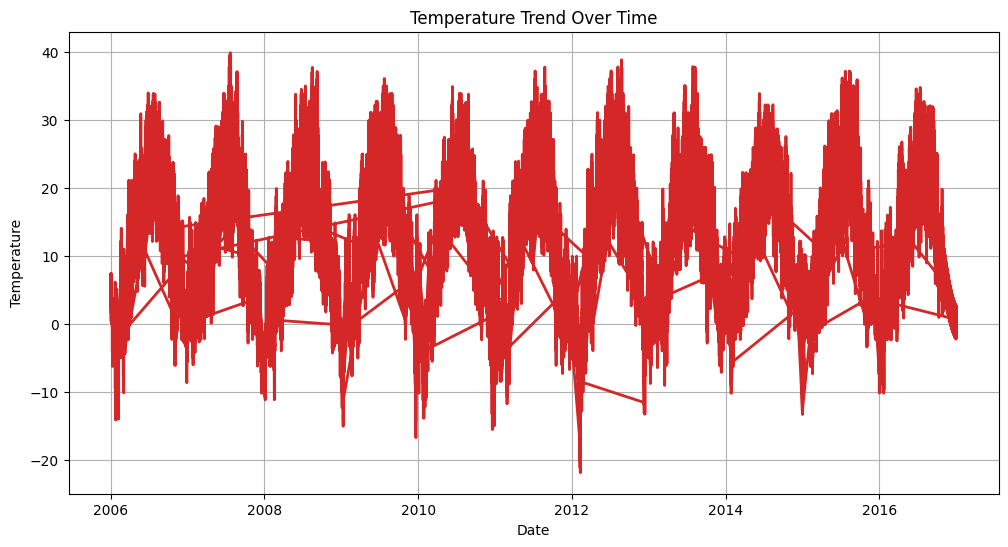

In [30]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Temperature (C)'], color='tab:red', linewidth=2)
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Temperature Trend Over Time")
plt.grid(True)
plt.show()

##**Graph Insight — Temperature Trends Over Time**
It displays the raw temp readings  from the dataset plotted against date/time axis.

  * Strong Annual Seasonality: The most dominant feature of this graph is the regular sinusoidal oscillation of temperature. Peaks (summer months) consistently reach ~30–40 °C, while troughs (winter months) drop to ~−10 to −20 °C.
  * Consistent Cycle Length: Each oscillation spans approximately 12 months, confirming a strong yearly seasonal pattern. This is a textbook indicator that the data is well-suited for time-series modelling.
  * No Obvious Long-Term Trend (Drift): The amplitude and baseline of the cycles appear relatively stable across years — there is no visible upward or downward drift over the full dataset span, which simplifies modelling.
  * High Frequency Noise: Within each seasonal cycle, there is considerable day-to-day (or hour-to-hour) variability visible as rapid fluctuations around the trend. This noise is why we later apply a rolling average.
  * Data Density: The near-vertical appearance at any given time-step (especially noticeable if hourly data) suggests dense temporal sampling, confirming we need a sequence-based model rather than point-in-time predictions.

In RNN Design
* The strong seasonality tells us that a sequence length of 14 days is a reasonable lookback window — enough to capture recent local context without needing the full seasonal cycle.
* The high-frequency noise reinforces the need for normalization (MinMaxScaler) and potentially dropout regularization.
* A SimpleRNN with sufficient hidden units (64) should be capable of learning these short-term patterns, though it may struggle with very long dependencies (a known SimpleRNN limitation).

Select Features

In [32]:
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']

data = df[features]

Normalize data

In [33]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

scaled_data.shape

(96453, 3)

# Create Sequences

Using previous 7 days to predict next day's temperature.

In [34]:
sequence_length = 7

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i,0])      # temperature is target

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(96446, 7, 3)
(96446,)


#Train, Validation and Test Split

In [35]:
train_size = int(len(X)*0.7)
val_size = int(len(X)*0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(67512, 7, 3)
(14466, 7, 3)
(14468, 7, 3)


---

# BUILD SIMPLE RNN MODEL

In [36]:
model = Sequential()

model.add(SimpleRNN(
    units=64,
    activation='tanh',
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(Dropout(0.2))

model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

Compile model

In [37]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

TRAIN MODEL

In [39]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0031 - mae: 0.0404 - val_loss: 7.0125e-04 - val_mae: 0.0206
Epoch 2/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0013 - mae: 0.0261 - val_loss: 5.2914e-04 - val_mae: 0.0172
Epoch 3/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 9.1179e-04 - mae: 0.0216 - val_loss: 4.1321e-04 - val_mae: 0.0138
Epoch 4/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 7.9631e-04 - mae: 0.0199 - val_loss: 4.2053e-04 - val_mae: 0.0143
Epoch 5/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 7.6779e-04 - mae: 0.0194 - val_loss: 4.3277e-04 - val_mae: 0.0144
Epoch 6/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 7.4535e-04 - mae: 0.0190 - val_loss: 4.2267e-04 - val_mae: 0.0146
Epoch 7/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 7.4013e-04 - mae: 0.0189 - val_loss: 4.4421e-04 - val_mae: 0.0142
Epoch 8/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 7.3587e-04 - mae: 0.0188 - val_loss: 4.0582e-04

## Plot Training and Validation Loss

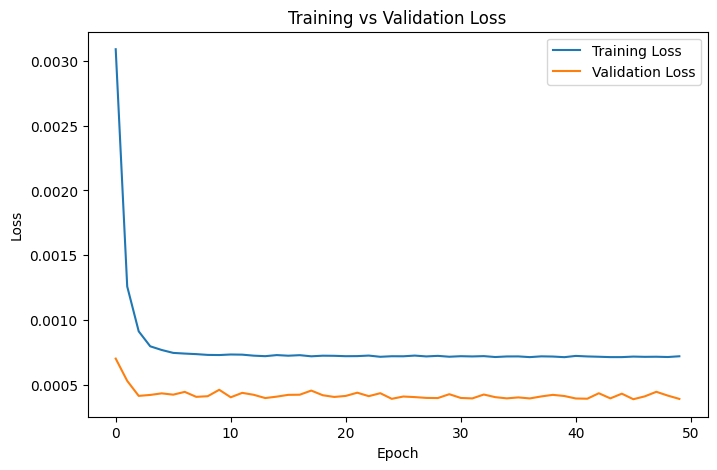

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.show()

---

# MODEL EVALUATION

predictions

In [42]:
y_pred = model.predict(X_test)

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


convert back to original scale

In [43]:
# temperature is the first feature

temp_min = scaler.data_min_[0]
temp_max = scaler.data_max_[0]

y_test_actual = y_test*(temp_max-temp_min)+temp_min
y_pred_actual = y_pred.flatten()*(temp_max-temp_min)+temp_min

Calculate RMSE, MAE and R²

In [44]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print("RMSE =", rmse)
print("MAE =", mae)
print("R2 Score =", r2)

RMSE = 1.165040185767797
MAE = 0.7818307665444101
R2 Score = 0.9830058059030212


Predicted vs Actual Temperatures

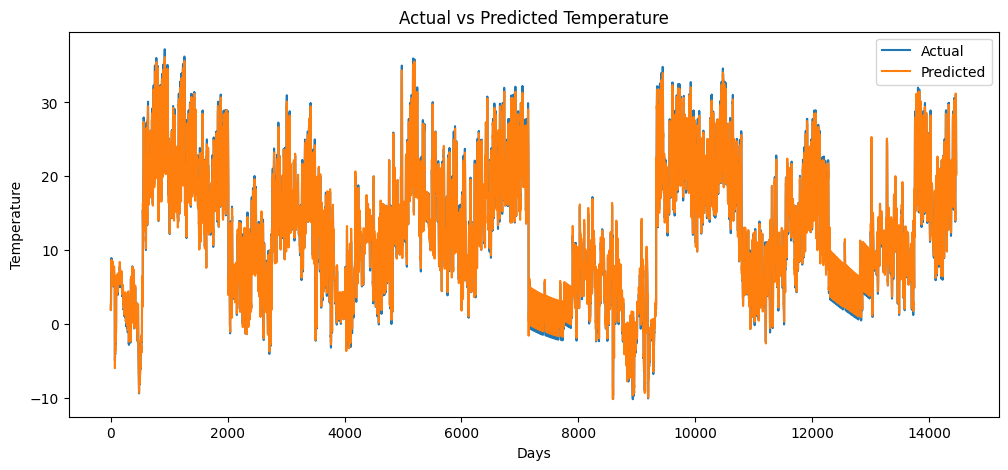

In [45]:
plt.figure(figsize=(12,5))

plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred_actual, label='Predicted')

plt.xlabel("Days")
plt.ylabel("Temperature")
plt.title("Actual vs Predicted Temperature")

plt.legend()
plt.show()

Forecast Next 7 Days

Take last sequence:

In [46]:
last_sequence = scaled_data[-sequence_length:]

future_predictions = []

current_sequence = last_sequence.copy()

for i in range(7):

    pred = model.predict(
        current_sequence.reshape(1,sequence_length,3),
        verbose=0
    )

    future_predictions.append(pred[0][0])

    next_row = current_sequence[-1].copy()
    next_row[0] = pred

    current_sequence = np.vstack((current_sequence[1:], next_row))

/tmp/ipykernel_12590/921947985.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_row[0] = pred


Convert Forecast to Original Temperature Scale

In [47]:
future_predictions = np.array(future_predictions)

future_temp = future_predictions*(temp_max-temp_min)+temp_min

print(future_temp)

[19.47311473 18.72353494 18.00913995 17.42669066 16.92460013 16.52685348
 16.19268449]


Plot Future Predictions

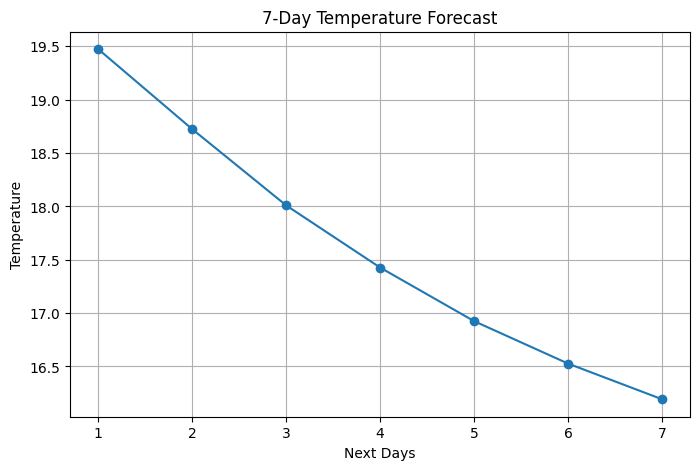

In [48]:
days = np.arange(1,8)

plt.figure(figsize=(8,5))

plt.plot(days, future_temp, marker='o')

plt.xlabel("Next Days")
plt.ylabel("Temperature")
plt.title("7-Day Temperature Forecast")

plt.grid()
plt.show()

# Model Architecture

Input Layer (7 × 3)

        ↓

SimpleRNN (64 units)

        ↓

Dropout (0.2)

        ↓

Dense (1 neuron)

        ↓
        
Predicted Temperature